# Importing Libraries 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,500.500000,288.819436,1.00,250.750,500.50,750.2500,1000.00
Distance_km,1000.0,10.059970,5.696656,0.59,5.105,10.19,15.0175,19.99
Preparation_Time_min,1000.0,16.982000,7.204553,5.00,11.000,17.00,23.0000,29.00
Courier_Experience_yrs,970.0,4.579381,2.914394,0.00,2.000,5.00,7.0000,9.00
Delivery_Time_min,1000.0,56.732000,22.070915,8.00,41.000,55.50,71.0000,153.00


# Basic Preprocessing

**Checking for Duplicates**

In [7]:
print(f'Number of duplicates in this dataset: {df.duplicated().sum()}')
df = df.drop_duplicates()

Number of duplicates in this dataset: 0


**Checking for missing values**

In [8]:
print(df.isnull().sum().sort_values(ascending=False))

Weather                   30
Time_of_Day               30
Traffic_Level             30
Courier_Experience_yrs    30
Order_ID                   0
Distance_km                0
Vehicle_Type               0
Preparation_Time_min       0
Delivery_Time_min          0
dtype: int64


In [9]:
# Fill categorical columns with mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical column with median
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())


In [10]:
print(df.isnull().sum().sort_values(ascending=False))

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


# EDA visuals

1. Delivery Time Distribution

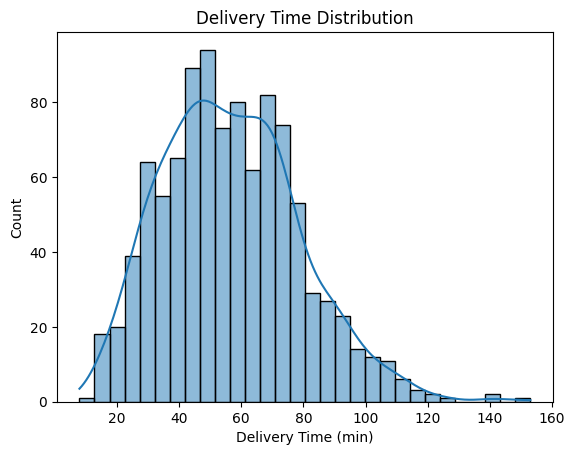

In [11]:
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (min)')
plt.show()

2. Vehicle Type vs Delivery Time

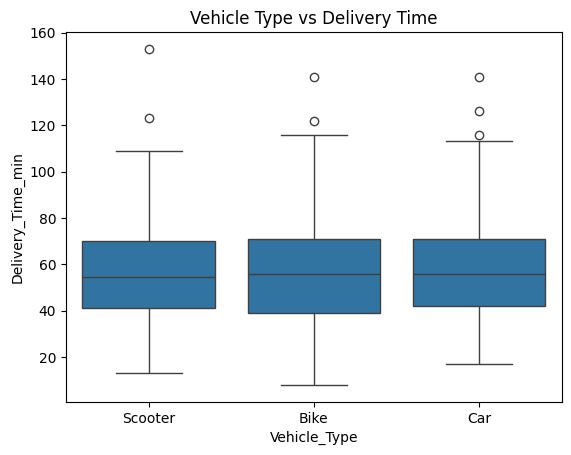

In [12]:
sns.boxplot(x='Vehicle_Type', y='Delivery_Time_min', data=df)
plt.title('Vehicle Type vs Delivery Time')
plt.show()

3. Weather vs Delivery Time

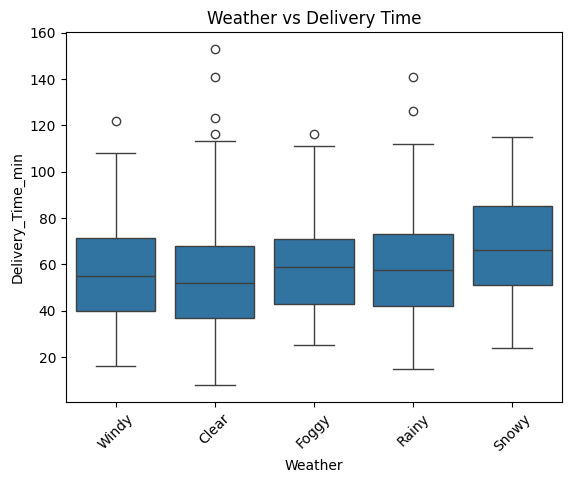

In [13]:
sns.boxplot(x='Weather', y='Delivery_Time_min', data=df)
plt.title('Weather vs Delivery Time')
plt.xticks(rotation=45)
plt.show()

4. Traffic Level vs Delivery Time

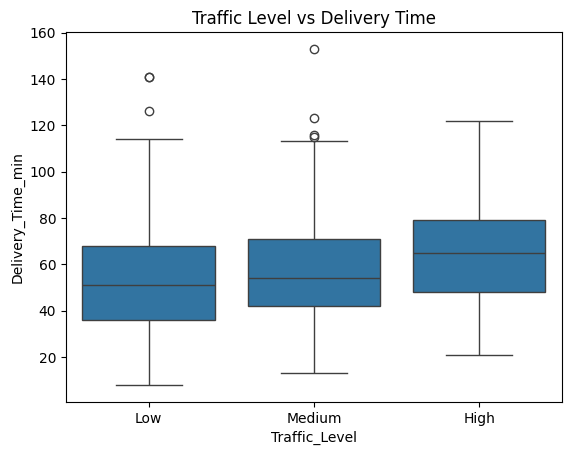

In [14]:
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df)
plt.title('Traffic Level vs Delivery Time')
plt.show()

5. Time of Day vs Delivery Time

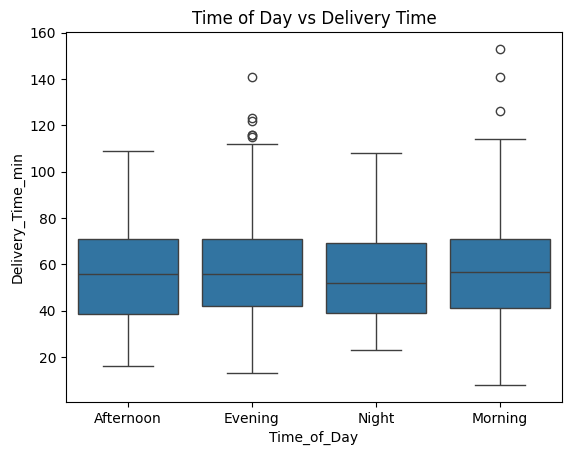

In [15]:
sns.boxplot(x='Time_of_Day', y='Delivery_Time_min', data=df)
plt.title('Time of Day vs Delivery Time')
plt.show()

6. Delivery Time by Courier Experience

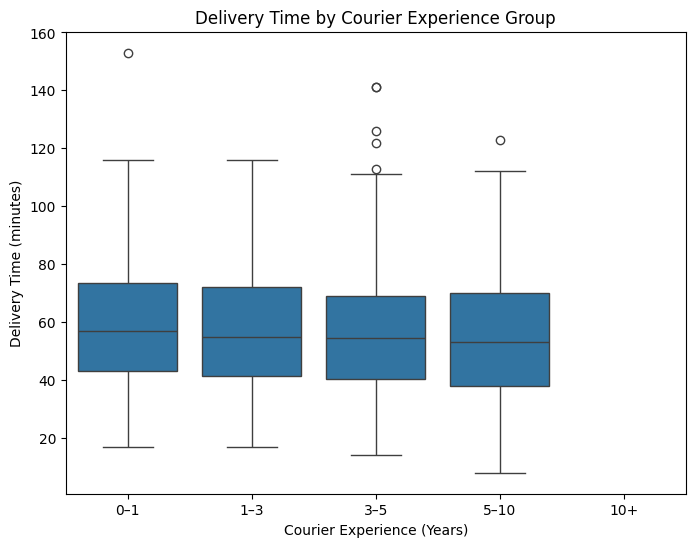

In [16]:
df['Experience_Group'] = pd.cut(df['Courier_Experience_yrs'], bins=[0, 1, 3, 5, 10, 20], 
                                labels=['0–1', '1–3', '3–5', '5–10', '10+'])

plt.figure(figsize=(8, 6))
sns.boxplot(x='Experience_Group', y='Delivery_Time_min', data=df)
plt.title("Delivery Time by Courier Experience Group")
plt.xlabel("Courier Experience (Years)")
plt.ylabel("Delivery Time (minutes)")
plt.show()


7. Correlation Heatmap

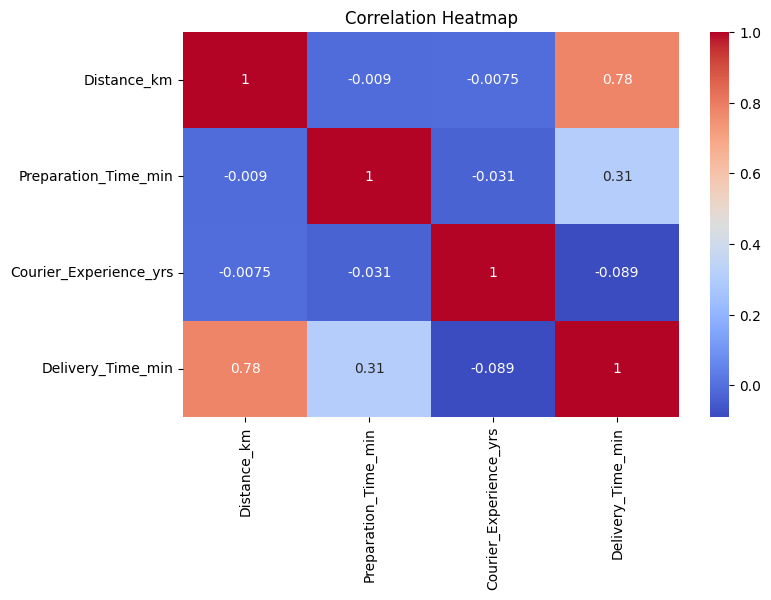

In [17]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Full Preprocessing Data

One-Hot Encoding Categorical Features

In [18]:
df = pd.get_dummies(df, 
                    columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], 
                    drop_first=True) 


In [19]:
df.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Experience_Group,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,0–1,False,False,False,True,True,False,False,False,False,False,True
1,738,16.42,20,2.0,84,1–3,False,False,False,False,False,True,True,False,False,False,False
2,741,9.52,28,1.0,59,0–1,True,False,False,False,True,False,False,False,True,False,True
3,661,7.44,5,1.0,37,0–1,False,True,False,False,False,True,False,False,False,False,True
4,412,19.03,16,5.0,68,3–5,False,False,False,False,True,False,False,True,False,False,False


In [20]:
if 'Experience_Group' in df.columns:
    df.drop('Experience_Group', axis=1, inplace=True)

# Modelling

Define Features & Target

In [21]:
X = df.drop(['Order_ID', 'Delivery_Time_min'], axis=1)
y = df['Delivery_Time_min']

Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.metrics import mean_absolute_error

1. Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))

Linear Regression MAE: 5.899168698353484


2. Decision Tree Regressor



In [25]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_dt))

Decision Tree MAE: 11.115


3. Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest MAE: 7.1429


4. Support Vector Regressor (SVR)

In [27]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

print("SVR MAE:", mean_absolute_error(y_test, y_pred_svr))

SVR MAE: 7.776288095254392


5. K-Nearest Neighbors Regressor

In [28]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN MAE:", mean_absolute_error(y_test, y_pred_knn))

KNN MAE: 8.567


# Boosting Models

1. XGBoost Regressor

In [29]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))

XGBoost MAE: 7.662957668304443


2. LightGBM Regressor

In [30]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM MAE:", mean_absolute_error(y_test, y_pred_lgbm))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 14
[LightGBM] [Info] Start training from score 57.053750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_27692\2945636455.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Predator Helios Neo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


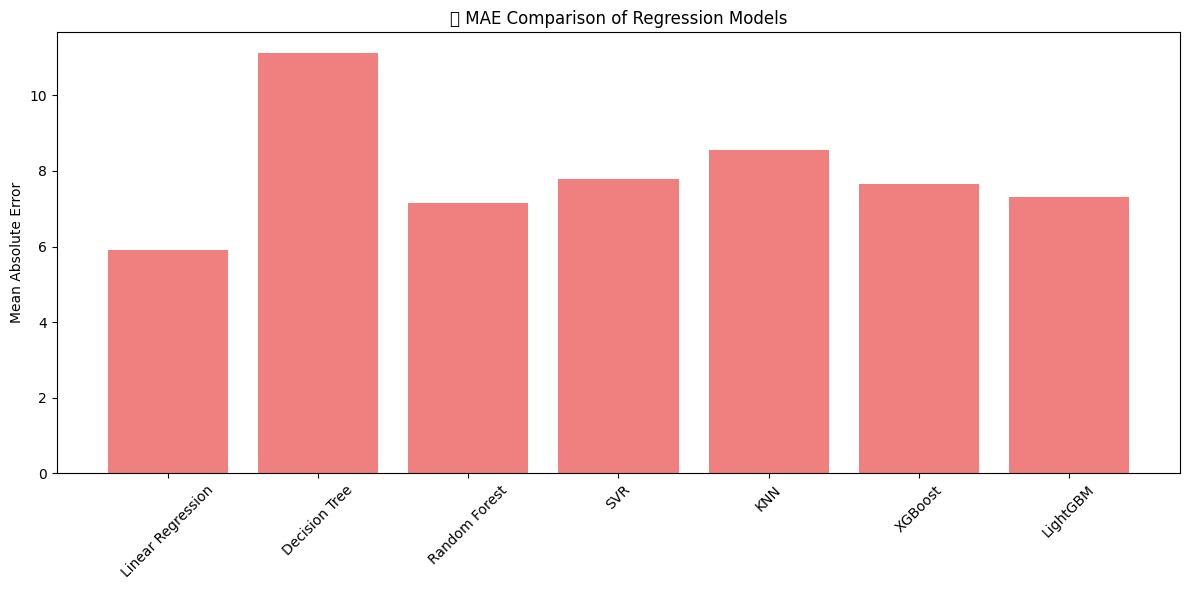

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Dictionary with all model MAEs
mae_scores = {
    'Linear Regression': mean_absolute_error(y_test, y_pred_lr),
    'Decision Tree': mean_absolute_error(y_test, y_pred_dt),
    'Random Forest': mean_absolute_error(y_test, y_pred_rf),
    'SVR': mean_absolute_error(y_test, y_pred_svr),
    'KNN': mean_absolute_error(y_test, y_pred_knn),
    'XGBoost': mean_absolute_error(y_test, y_pred_xgb),
    'LightGBM': mean_absolute_error(y_test, y_pred_lgbm)
}

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(mae_scores.keys(), mae_scores.values(), color='lightcoral')
plt.ylabel("Mean Absolute Error")
plt.title("📊 MAE Comparison of Regression Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [46]:
mae_scores = {
    'Linear Regression': mean_absolute_error(y_test, y_pred_lr),
    'Decision Tree': mean_absolute_error(y_test, y_pred_dt),
    'Random Forest': mean_absolute_error(y_test, y_pred_rf),
    'SVR': mean_absolute_error(y_test, y_pred_svr),
    'KNN': mean_absolute_error(y_test, y_pred_knn),
    'XGBoost': mean_absolute_error(y_test, y_pred_xgb),
    'LightGBM': mean_absolute_error(y_test, y_pred_lgbm)
}
mae_scores

{'Linear Regression': 5.899168698353484,
 'Decision Tree': 11.115,
 'Random Forest': 7.1429,
 'SVR': 7.776288095254392,
 'KNN': 8.567,
 'XGBoost': 6.463638782501221,
 'LightGBM': 6.851637761904222}

# Tuning Model

1. Ridge Regression (L2 Regularization)

In [32]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge = Ridge()
ridge_grid = GridSearchCV(ridge, ridge_params, scoring='neg_mean_absolute_error', cv=5)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print("Ridge MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("Best Alpha:", ridge_grid.best_params_['alpha'])


Ridge MAE: 5.910047471377681
Best Alpha: 1


2. Lasso Regression (L1 Regularization)

In [33]:
from sklearn.linear_model import Lasso

lasso_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

lasso = Lasso()
lasso_grid = GridSearchCV(lasso, lasso_params, scoring='neg_mean_absolute_error', cv=5)
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

print("Lasso MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("Best Alpha:", lasso_grid.best_params_['alpha'])

Lasso MAE: 5.914658095147576
Best Alpha: 0.01


**Linear vs Ridge vs Lasso Comparison**

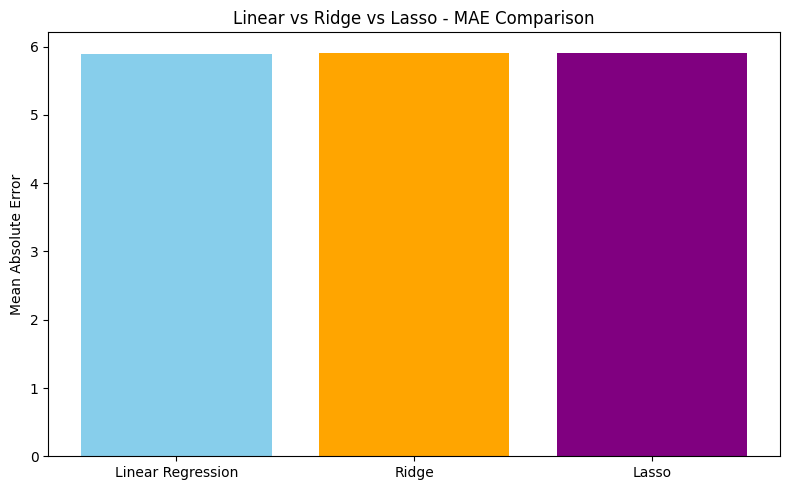

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Collect MAEs
mae_compare = {
    'Linear Regression': mean_absolute_error(y_test, y_pred_lr),
    'Ridge': mean_absolute_error(y_test, y_pred_ridge),
    'Lasso': mean_absolute_error(y_test, y_pred_lasso)
}

# Plot
plt.figure(figsize=(8, 5))
plt.bar(mae_compare.keys(), mae_compare.values(), color=['skyblue', 'orange', 'purple'])
plt.ylabel("Mean Absolute Error")
plt.title("Linear vs Ridge vs Lasso - MAE Comparison")
plt.tight_layout()
plt.show()


In [47]:
mae_compare

{'Linear Regression': 5.899168698353484,
 'Ridge': 5.910047471377681,
 'Lasso': 5.914658095147576}

Since Linear, Ridge, and Lasso gave similar results, let’s move forward.

Random Forest Hyperparameter Tuning

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(estimator=rf,
                       param_grid=param_grid,
                       cv=3,
                       scoring='neg_mean_absolute_error',
                       n_jobs=-1,
                       verbose=1)

grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Tuned RF MAE:", mean_absolute_error(y_test, y_pred_best_rf))
print("Best Params:", grid_rf.best_params_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tuned RF MAE: 6.975427650439839
Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


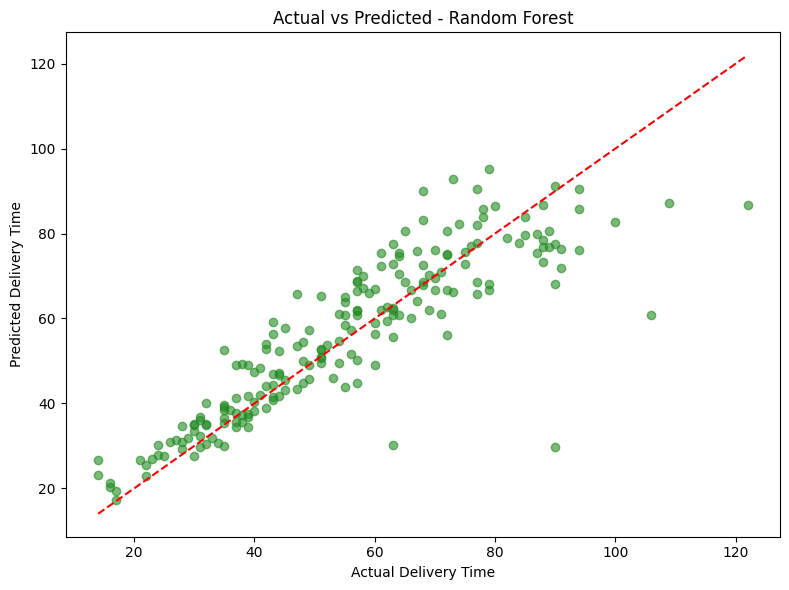

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best_rf, color='forestgreen', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted - Random Forest")
plt.tight_layout()
plt.show()

**MAE Comparison – Random Forest vs Linear**

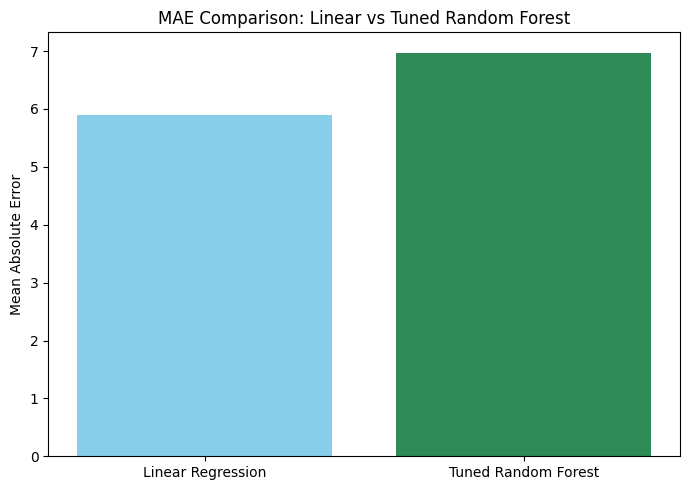

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# MAE values
mae_scores = {
    'Linear Regression': mean_absolute_error(y_test, y_pred_lr),
    'Tuned Random Forest': mean_absolute_error(y_test, y_pred_best_rf)
}

# Plot
plt.figure(figsize=(7, 5))
plt.bar(mae_scores.keys(), mae_scores.values(), color=['skyblue', 'seagreen'])
plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison: Linear vs Tuned Random Forest")
plt.tight_layout()
plt.show()


 Tuning LightGBM Regressor

In [38]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

lgbm = LGBMRegressor(random_state=42)

grid_lgbm = GridSearchCV(estimator=lgbm,
                         param_grid=param_grid,
                         cv=3,
                         scoring='neg_mean_absolute_error',
                         n_jobs=-1,
                         verbose=1)

grid_lgbm.fit(X_train, y_train)

# Best model
best_lgbm = grid_lgbm.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test)

print("Tuned LGBM MAE:", mean_absolute_error(y_test, y_pred_lgbm))
print("Best Params:", grid_lgbm.best_params_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 14
[LightGBM] [Info] Start training from score 57.053750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

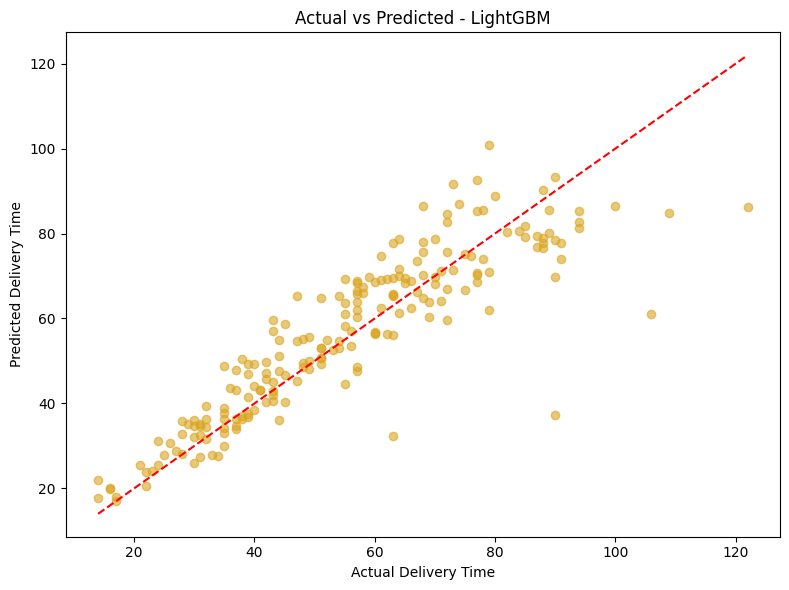

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lgbm, color='goldenrod', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted - LightGBM")
plt.tight_layout()
plt.show()


**MAE Comparison: Linear vs RF vs LightGBM**

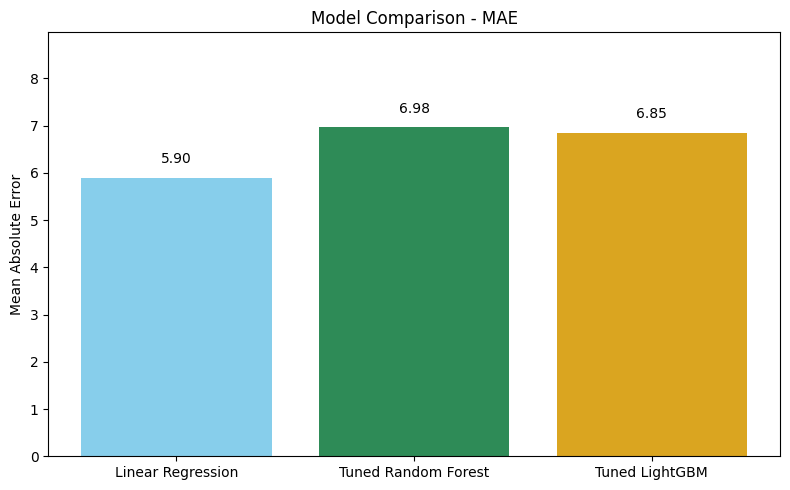

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# MAE values
mae_scores = {
    'Linear Regression': mean_absolute_error(y_test, y_pred_lr),
    'Tuned Random Forest': mean_absolute_error(y_test, y_pred_best_rf),
    'Tuned LightGBM': mean_absolute_error(y_test, y_pred_lgbm)
}

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(mae_scores.keys(), mae_scores.values(), color=['skyblue', 'seagreen', 'goldenrod'])
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison - MAE")
plt.ylim(0, max(mae_scores.values()) + 2)

# Add MAE values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


XGBoost Hyperparameter Tuning

In [41]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)

grid_xgb = GridSearchCV(estimator=xgb,
                        param_grid=param_grid,
                        cv=3,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1,
                        verbose=1)

grid_xgb.fit(X_train, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("Tuned XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("Best Params:", grid_xgb.best_params_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tuned XGBoost MAE: 6.463638782501221
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


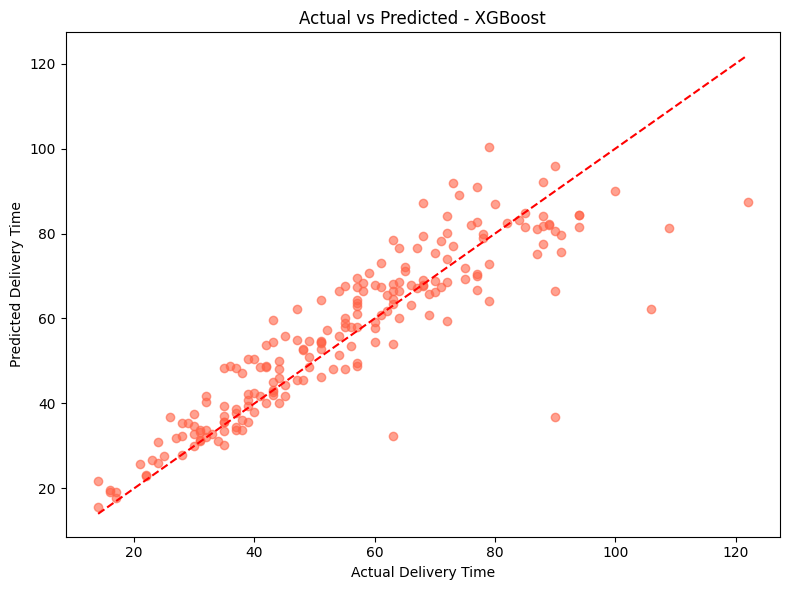

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, color='tomato', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted - XGBoost")
plt.tight_layout()
plt.show()


**MAE Comparison**

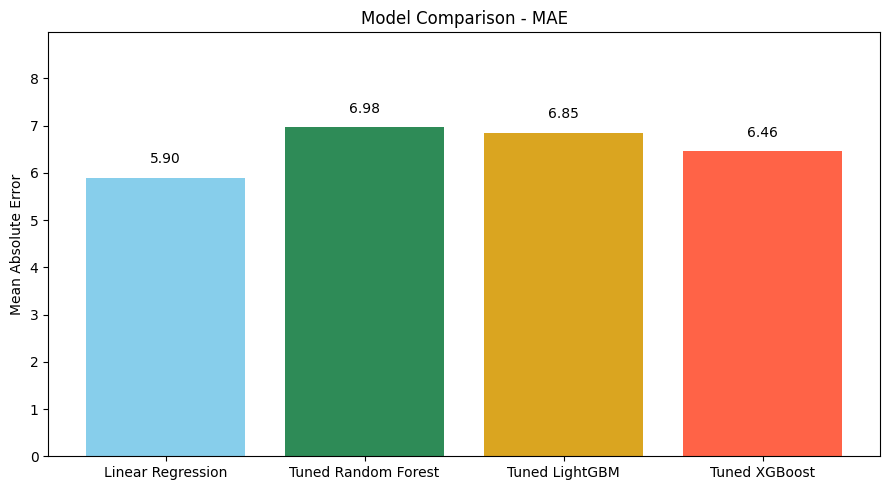

In [43]:
mae_scores = {
    'Linear Regression': mean_absolute_error(y_test, y_pred_lr),
    'Tuned Random Forest': mean_absolute_error(y_test, y_pred_best_rf),
    'Tuned LightGBM': mean_absolute_error(y_test, y_pred_lgbm),
    'Tuned XGBoost': mean_absolute_error(y_test, y_pred_xgb)
}

plt.figure(figsize=(9, 5))
bars = plt.bar(mae_scores.keys(), mae_scores.values(), color=['skyblue', 'seagreen', 'goldenrod', 'tomato'])
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison - MAE")
plt.ylim(0, max(mae_scores.values()) + 2)

# Add MAE labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{height:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


# Conclusion
After evaluating multiple models—Linear Regression, Random Forest, LightGBM, and XGBoost—based on their Mean Absolute Error (MAE), we found that:

🔹 **Linear Regression** consistently delivered the lowest MAE, making it the most effective model for predicting delivery time in this dataset.

Despite experimenting with various boosting and ensemble techniques, the simplicity and effectiveness of Linear Regression prevailed, suggesting a strong linear relationship between the features and the target variable.

Therefore, Linear Regression is selected as the final model for deployment.

